# **DA11_ML_Assignment**
# **Airbnb Price Prediction Assignment**
# **Submitted By: Muhammad Anas Nasir**

-------

## **Task 01: Data Loading and Preprocessing**

### **Step 01: Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures

In [3]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### **Step 02: Load the dataset**

In [4]:
data = pd.read_csv('airbnb.csv')

In [5]:
# display the first few rows of the dataset
data.head()

,id,name,host_id,host_name,neighbourhood group,neighbourhood,latitude,longitude,room type,price,minimum nights,number_of_reviews,last review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1.0,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1.0,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3.0,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1.0,270,7/5/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10.0,9,11/19/2018,0.10,1,0


### **Step 03: Dataset info**

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48900 entries, 0 to 48899
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48900 non-null  int64  
 1   name                            48884 non-null  object 
 2   host_id                         48900 non-null  int64  
 3   host_name                       48879 non-null  object 
 4   neighbourhood group             48900 non-null  object 
 5   neighbourhood                   48900 non-null  object 
 6   latitude                        48900 non-null  float64
 7   longitude                       48900 non-null  float64
 8   room type                       48900 non-null  object 
 9   price                           48900 non-null  float64
 10  minimum nights                  48900 non-null  float64
 11  number_of_reviews               48900 non-null  int64  
 12  last review                     

### **Step 04: Check Missing Values and Duplicates**

In [10]:
print("Missing Values:")
print(data.isnull().sum())
print("Duplicates:")
print(data.duplicated().sum())

Missing Values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room type                             0
price                                 0
minimum nights                        0
number_of_reviews                     0
last review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64
Duplicates:
5


### **Step 05: Remove Duplicates**

In [11]:
data.drop_duplicates()

,id,name,host_id,host_name,neighbourhood group,neighbourhood,latitude,longitude,room type,price,minimum nights,number_of_reviews,last review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1.0,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1.0,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3.0,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1.0,270,7/5/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10.0,9,11/19/2018,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48895,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70.0,2.0,0,NaN,NaN,2,9
48896,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40.0,4.0,0,NaN,NaN,2,36
48897,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115.0,10.0,0,NaN,NaN,1,27
48898,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55.0,1.0,0,NaN,NaN,6,2


### **Step 06: Handle Missing Values**

In [13]:
# Fill numerical columns with median.

num_cols = data.select_dtypes(include = np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

In [15]:
# Fill categorical columns with mode

cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
     data[col] = data[col].fillna(data[col].mode()[0])

### **Step 07: Drop Irrelvant Columns**

In [17]:
data = data.drop(['id', 'name', 'host_id', 'host_name', 'last review'], axis=1)

### **Step 08: Encode categorical features**

In [18]:
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

### **Step 09: Split Features and Target**

In [20]:
X = data.drop('price', axis=1)
y = data['price']

### **Step 10: Train-Test Split**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Task 02: Linear Regression**
### **Step 01: Train Model**

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### **Step 02: Predictions**

In [23]:
y_pred = lr.predict(X_test)

### **Step 03: Evaluation Metrics**

In [24]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Squared Error: 60454.59041827221
Root Mean Squared Error: 245.87515209608353
Mean Absolute Error: 76.32939905556039
R-squared: 0.07709817634003746


### **Step 04: Coefficients and Intercept**

In [25]:
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

Intercept: -51139.754523840544
Coefficients: [ 1.05524818e+01  8.63010346e-02  1.39069995e+02 -6.16963696e+02
 -1.00264200e+02  7.21251437e-03 -3.36363517e-01  4.43566734e-01
 -1.07347813e-01  2.06952243e-01]


## **Task 3: Visualization**
### **01. Actual vs Predicted**

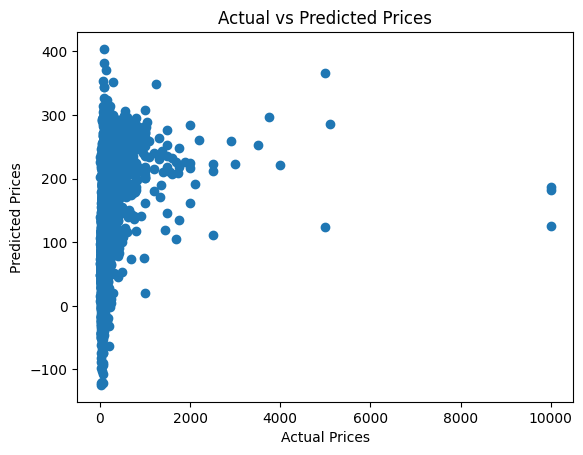

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

### **2. Residual Plot**

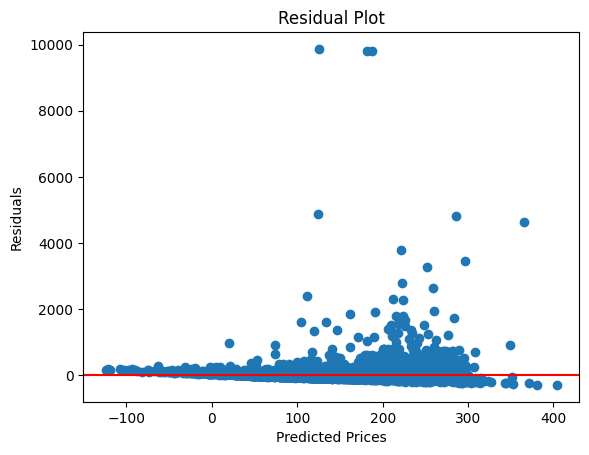

In [29]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### **3. Histogram of Residuals**

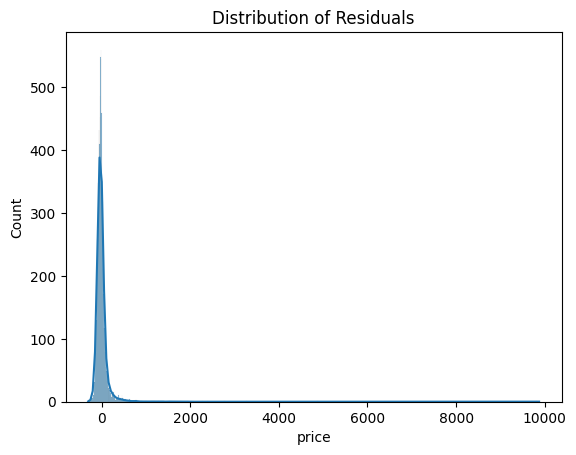

In [30]:
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

## **Task 04: Polynomial, Ridge, and Lasso Regression**

### **01. Polynomial Regression (Degree = 2)**

In [31]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

### **02. Ridge Regression**

In [32]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

### **03. Lasso Regression**

In [33]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

### **04. Evaluation Function**

In [34]:
def evaluate_model(y_test, y_pred, model_name):
     mse = mean_squared_error(y_test, y_pred)
     rmse = np.sqrt(mse)
     mae = mean_absolute_error(y_test, y_pred)
     r2 = r2_score(y_test, y_pred)
     return mse, rmse, mae, r2

### **05. Compare all models**

In [37]:
results = pd.DataFrame([
     ('Linear', *evaluate_model(y_test, y_pred, 'Linear')),
     ('Polynomial', *evaluate_model(y_test, y_pred_poly, 'Polynomial')),
     ('Ridge', *evaluate_model(y_test, y_pred_ridge, 'Ridge')),
     ('Lasso', *evaluate_model(y_test, y_pred_lasso, 'Lasso'))
], columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2 Score'])

results

results.T

,0,1,2,3
Model,Linear,Polynomial,Ridge,Lasso
MSE,60454.590418,59470.032466,60454.5612,60462.162048
RMSE,245.875152,243.864783,245.875093,245.890549
MAE,76.329399,72.444979,76.298599,76.097083
R2 Score,0.077098,0.092128,0.077099,0.076983


### **06. Best Model**
--------

**Conclusion Logic:**

- Lowest RMSE & MAE = better accuracy
- Highest R² Score = better fit

**Example:**

Polynomial Regression performed best as it captured non-linear relationships, resulting in higher R (square) and lower error values compared to other models.

# **Final Conclusion**
---

- Lnear Regression provides a baseline model.

- Polynomial regression captures complex relationships.

- Ridge reduces overfitting using regularization.

- Lasso performs feature selection by shrinking coefficients

The best model depends on:

- Highest R (square)
- Lowest RMSE (Root Mean Square Error)